In [171]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


**Загружаем датасет**

In [172]:
iris = load_iris()

**Для визуализации возьмём 2 признака и 2 класса**

In [173]:

X = iris.data[:, 2:4]  # petal length, petal width
y = iris.target

**Оставим только два класса (0 и 1)**

In [174]:
mask = y > 0
X = X[mask]
y = y[mask] - 1

**Нормализация**

In [175]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Преобразуем *Y* в столбец**

In [176]:
y = y.reshape(-1, 1)

**Функции аквтивации**

In [177]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


In [178]:
class Neuron:
    def __init__(self, n_inputs):
        self.w = np.random.randn(n_inputs, 1)
        self.b = 0

    def forward(self, X):
        self.z = X @ self.w + self.b
        self.a = sigmoid(self.z)
        return self.a

    def backward(self, X, y, lr):
        m = len(y)
        dz = self.a - y
        dw = (1 / m) * X.T @ dz
        db = (1 / m) * np.sum(dz)

        self.w -= lr * dw
        self.b -= lr * db


**Обучение нейрона**

In [179]:
neuron = Neuron(n_inputs=2)

epochs = 100000
lr = 0.1

for epoch in range(epochs):
    y_pred = neuron.forward(X)
    neuron.backward(X, y, lr)


In [180]:
y_pred_class = (neuron.forward(X) > 0.5).astype(int)

print("Один нейрон:")
print("Accuracy:", accuracy_score(y, y_pred_class))
print("Precision:", precision_score(y, y_pred_class))
print("Recall:", recall_score(y, y_pred_class))
print("F1:", f1_score(y, y_pred_class))


Один нейрон:
Accuracy: 0.94
Precision: 0.94
Recall: 0.94
F1: 0.94


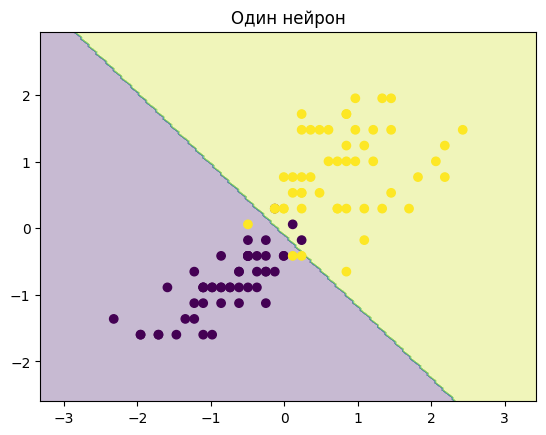

In [181]:
def plot_decision_boundary_neuron(neuron, X, y, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = (neuron.forward(grid) > 0.5).astype(int)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten())
    plt.title(title)
    plt.show()

plot_decision_boundary_neuron(neuron, X, y, "Один нейрон")


In [182]:
class NeuralNetwork:
    def __init__(self, n_inputs, n_hidden, n_outputs):
        self.W1 = np.random.randn(n_inputs, n_hidden)
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = np.random.randn(n_hidden, n_outputs)
        self.b2 = np.zeros((1, n_outputs))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, lr):
        m = len(y)

        dz2 = self.a2 - y
        dW2 = (1 / m) * self.a1.T @ dz2
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)

        dz1 = (dz2 @ self.W2.T) * sigmoid_derivative(self.z1)
        dW1 = (1 / m) * X.T @ dz1
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1


In [183]:
nn = NeuralNetwork(n_inputs=2, n_hidden=10, n_outputs=1)

epochs = 100000
lr = 0.1

for epoch in range(epochs):
    nn.forward(X)
    nn.backward(X, y, lr)


In [184]:
y_pred_nn = (nn.forward(X) > 0.5).astype(int)

print("Нейросеть 2×10:")
print("Accuracy:", accuracy_score(y, y_pred_nn))
print("Precision:", precision_score(y, y_pred_nn))
print("Recall:", recall_score(y, y_pred_nn))
print("F1:", f1_score(y, y_pred_nn))


Нейросеть 2×10:
Accuracy: 0.99
Precision: 0.9803921568627451
Recall: 1.0
F1: 0.9900990099009901


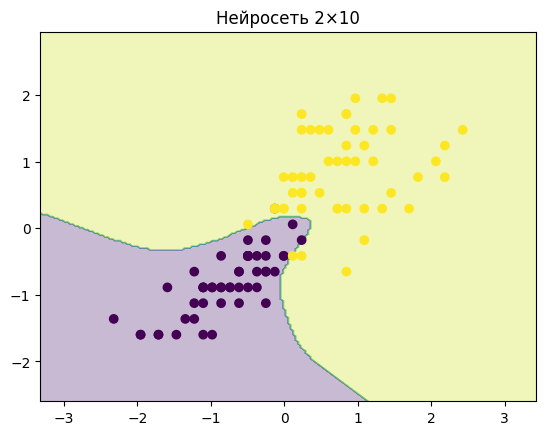

In [185]:
def plot_decision_boundary_nn(nn, X, y, title):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = (nn.forward(grid) > 0.5).astype(int)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten())
    plt.title(title)
    plt.show()

plot_decision_boundary_nn(nn, X, y, "Нейросеть 2×10")


**Сравнение метрик**

In [186]:
import pandas as pd

metrics = pd.DataFrame({
    "Модель": ["Один нейрон", "Нейросеть 2×10"],
    "Accuracy": [
        accuracy_score(y, y_pred_class),
        accuracy_score(y, y_pred_nn)
    ],
    "Precision": [
        precision_score(y, y_pred_class),
        precision_score(y, y_pred_nn)
    ],
    "Recall": [
        recall_score(y, y_pred_class),
        recall_score(y, y_pred_nn)
    ],
    "F1-score": [
        f1_score(y, y_pred_class),
        f1_score(y, y_pred_nn)
    ]
})

metrics


,Модель,Accuracy,Precision,Recall,F1-score
0,Один нейрон,0.94,0.940000,0.94,0.940000
1,Нейросеть 2×10,0.99,0.980392,1.00,0.990099


### Сравнение метрик классификации

В таблице представлены значения метрик качества классификации для однослойного нейрона и многослойной нейросети.

Как видно из таблицы, однослойный нейрон достигает высокой точности (94%), однако многослойная нейросеть с двумя скрытыми слоями по 10 нейронов позволяет улучшить все метрики, особенно Recall и F1-score. Это связано с тем, что выбранная подвыборка датасета теперь **не полностью линейно разделима**, и более сложная модель способна построить более точную разделяющую границу между классами.

Таким образом, сравнение показывает, что **увеличение глубины и числа нейронов позволяет повысить качество классификации на сложных для линейного разделения данных**.